# MSCS-634-B01: Advanced Big Data and Data Mining
## Project Deliverable 1: Data Collection, Cleaning, and Exploration
**Name:** Aashish Sapkota
**Course:** MSCS-634-B01, Summer 2026

## Dataset Selection and Justification

**Dataset:** Historical Weather (Szeged, Hungary) — sourced from Kaggle
(budincsevity/szeged-weather)

**Description:** This dataset contains 96,453 hourly weather observations recorded
in Szeged, Hungary, spanning multiple years. It includes 12 attributes: timestamp,
weather summary, precipitation type, temperature, apparent temperature, humidity,
wind speed, wind bearing, visibility, cloud cover, atmospheric pressure, and a daily
summary description.

**Why this dataset is appropriate for the project:**
- **Size:** At 96,453 rows, it comfortably exceeds typical minimum size requirements
  for meaningful statistical analysis and machine learning.
- **Mix of attribute types:** It includes continuous numeric features (temperature,
  humidity, pressure), categorical features (precipitation type, summary), and a
  timestamp that can be engineered into additional features (month, hour) — giving
  room to demonstrate a range of data mining techniques.
- **Real-world messiness:** The dataset contains genuine missing values, outliers,
  and at least one categorical field with class imbalance, making it a realistic
  candidate for demonstrating data cleaning and preprocessing skills rather than a
  synthetic, already-clean dataset.
- **Natural regression target:** Temperature is a continuous variable with clear,
  physically meaningful relationships to other features (e.g., humidity, precipitation
  type), making it well suited to the regression modeling required in later project
  deliverables.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("weatherHistory.csv")
df["Formatted Date"] = pd.to_datetime(df["Formatted Date"], utc=True)
df = df.sort_values("Formatted Date").reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (96453, 12)


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2005-12-31 23:00:00+00:00,Partly Cloudy,rain,0.577778,-4.050000,0.89,17.1143,140.0,9.9820,0.0,1016.66,Mostly cloudy throughout the day.
1,2006-01-01 00:00:00+00:00,Mostly Cloudy,rain,1.161111,-3.238889,0.85,16.6152,139.0,9.9015,0.0,1016.15,Mostly cloudy throughout the day.
2,2006-01-01 01:00:00+00:00,Mostly Cloudy,rain,1.666667,-3.155556,0.82,20.2538,140.0,9.9015,0.0,1015.87,Mostly cloudy throughout the day.
3,2006-01-01 02:00:00+00:00,Overcast,rain,1.711111,-2.194444,0.82,14.4900,140.0,9.9015,0.0,1015.56,Mostly cloudy throughout the day.
4,2006-01-01 03:00:00+00:00,Mostly Cloudy,rain,1.183333,-2.744444,0.86,13.9426,134.0,9.9015,0.0,1014.98,Mostly cloudy throughout the day.


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype              
---  ------                    --------------  -----              
 0   Formatted Date            96453 non-null  datetime64[us, UTC]
 1   Summary                   96453 non-null  str                
 2   Precip Type               95936 non-null  str                
 3   Temperature (C)           96453 non-null  float64            
 4   Apparent Temperature (C)  96453 non-null  float64            
 5   Humidity                  96453 non-null  float64            
 6   Wind Speed (km/h)         96453 non-null  float64            
 7   Wind Bearing (degrees)    96453 non-null  float64            
 8   Visibility (km)           96453 non-null  float64            
 9   Loud Cover                96453 non-null  float64            
 10  Pressure (millibars)      96453 non-null  float64            
 11  Daily Summary             

In [3]:
duplicate_count = df.duplicated().sum()
print(f"Number of exact duplicate rows: {duplicate_count}")

Number of exact duplicate rows: 24


In [4]:
print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64


In [5]:
# Precip Type is categorical with missing values — fill using the mode,
# since dropping ~0.5% of rows outright would lose otherwise-complete records
df["Precip Type"] = df["Precip Type"].fillna(df["Precip Type"].mode()[0])

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Formatted Date              0
Summary                     0
Precip Type                 0
Temperature (C)             0
Apparent Temperature (C)    0
Humidity                    0
Wind Speed (km/h)           0
Wind Bearing (degrees)      0
Visibility (km)             0
Loud Cover                  0
Pressure (millibars)        0
Daily Summary               0
dtype: int64


In [6]:
# Check for physically implausible values that would indicate sensor/data errors
print("Humidity range:", df["Humidity"].min(), "to", df["Humidity"].max())
print("Pressure range:", df["Pressure (millibars)"].min(), "to", df["Pressure (millibars)"].max())
print("Rows with Pressure = 0 (likely sensor error):", (df["Pressure (millibars)"] == 0).sum())

Humidity range: 0.0 to 1.0
Pressure range: 0.0 to 1046.38
Rows with Pressure = 0 (likely sensor error): 1288


In [7]:
# Pressure readings of exactly 0 millibars are physically impossible at sea level
# and represent sensor error, not real atmospheric conditions
zero_pressure_count = (df["Pressure (millibars)"] == 0).sum()
df = df[df["Pressure (millibars)"] != 0].reset_index(drop=True)

print(f"Removed {zero_pressure_count} rows with erroneous zero-pressure readings")
print(f"Dataset shape after cleaning: {df.shape}")

Removed 1288 rows with erroneous zero-pressure readings
Dataset shape after cleaning: (95165, 12)


In [8]:
# Loud Cover is a constant (always 0) and Daily Summary is unstructured free text —
# neither contributes to numerical analysis
df = df.drop(columns=["Loud Cover", "Daily Summary"])
print("Columns after cleaning:", list(df.columns))

Columns after cleaning: ['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)', 'Pressure (millibars)']


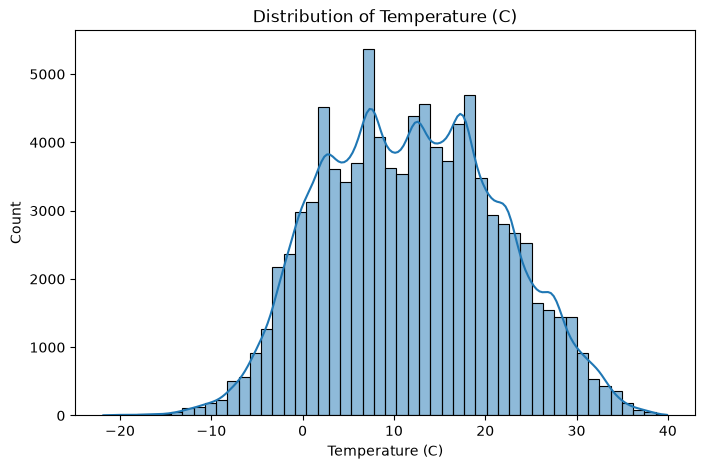

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df["Temperature (C)"], bins=50, kde=True)
plt.title("Distribution of Temperature (C)")
plt.xlabel("Temperature (C)")
plt.show()

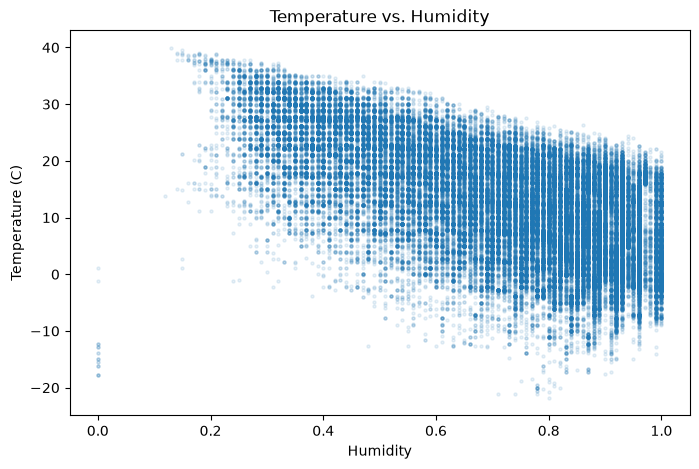

In [10]:
plt.figure(figsize=(8,5))
plt.scatter(df["Humidity"], df["Temperature (C)"], alpha=0.1, s=5)
plt.xlabel("Humidity")
plt.ylabel("Temperature (C)")
plt.title("Temperature vs. Humidity")
plt.show()

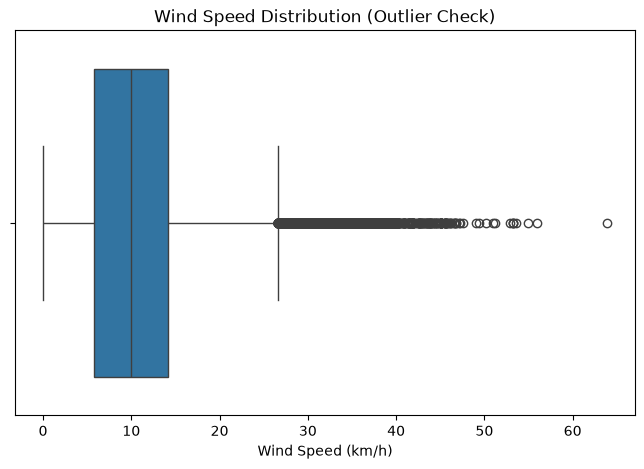

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Wind Speed (km/h)"])
plt.title("Wind Speed Distribution (Outlier Check)")
plt.show()

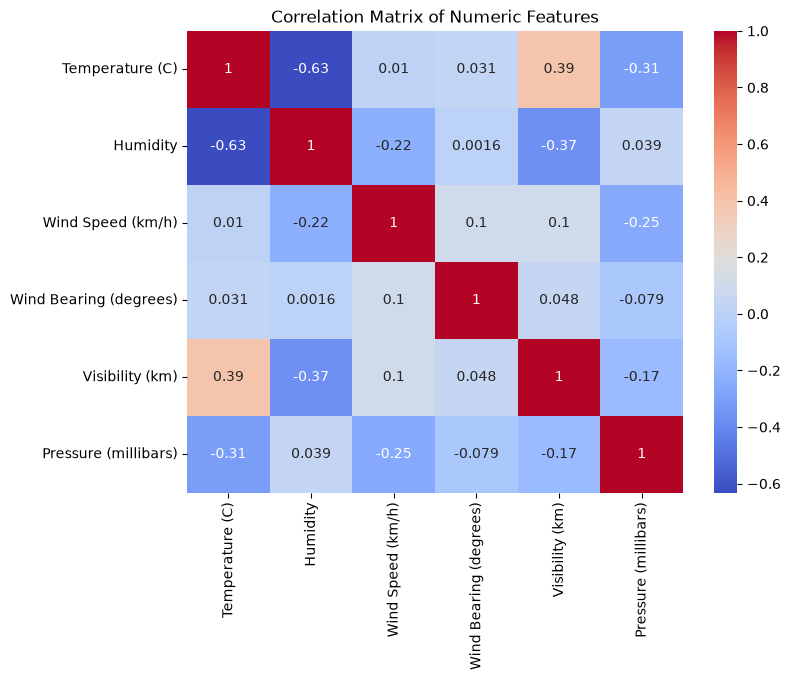

In [12]:
numeric_cols = ["Temperature (C)", "Humidity", "Wind Speed (km/h)",
                 "Wind Bearing (degrees)", "Visibility (km)", "Pressure (millibars)"]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Numeric Features")
plt.show()

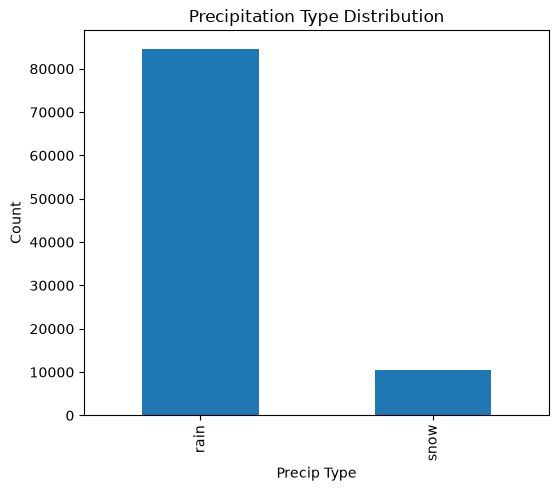

In [13]:
plt.figure(figsize=(6,5))
df["Precip Type"].value_counts().plot(kind="bar")
plt.title("Precipitation Type Distribution")
plt.xlabel("Precip Type")
plt.ylabel("Count")
plt.show()

## Insights from Exploratory Data Analysis

- **Temperature is roughly bell-shaped** with a slight spread toward warmer values,
  suggesting it is well suited to linear modeling techniques without requiring a
  transformation.
- **Humidity shows a strong negative relationship with Temperature** (visible in the
  scatter plot and confirmed by the correlation heatmap, r ≈ -0.64). This is the
  single strongest relationship in the dataset and indicates Humidity should be a
  primary feature in any regression model predicting Temperature.
- **Wind Speed contains a meaningful number of outliers** — the box plot shows a long
  tail of high-speed readings well above the interquartile range. These should be
  addressed (e.g., via IQR-based filtering) before being used in distance-based or
  regression models, where extreme values can disproportionately influence results.
- **Precipitation Type is heavily imbalanced**, with "rain" dominating and "snow"
  appearing far less frequently. This class imbalance is worth accounting for in any
  future classification modeling that uses this feature as a target or predictor.
- **Pressure contained a cluster of erroneous zero readings**, which were removed as
  noise; this step was necessary to avoid these sensor errors distorting statistical
  summaries and regression coefficients in later modeling.

These insights directly inform the modeling approach for the next project phase:
Humidity, Wind Speed, and Precip Type are strong candidate features for predicting
Temperature via regression, while the identified outliers and noisy readings confirm
that the cleaning steps performed in this deliverable were necessary groundwork for
producing reliable models.